## Basic Setup

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.layers import Dense, Flatten, Input, Dropout, BatchNormalization
from keras.models import Sequential, Model
from keras.optimizers import SGD
from keras.applications import MobileNetV2
from keras.regularizers import l2

os.chdir('../../../') # move three level up to the base path
from src.utils import load_and_preprocess_images, plot_history
from src.model_evaluation import evaluate_model
from src.plot_images import plot_images, plot_predictions, plot_false_positives, plot_false_negatives

In [3]:
# set the random seeds to make sure that the results are reproducible
SEED = 1234
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

In [4]:
model_name = '2_finetuned_real_eyes'
repo_path = '/Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection'

realDataPath = repo_path + '/data/CEW_Data_Test_Train'
realTrainingPath = realDataPath + '/TrainingSet'
realTestPath = realDataPath + '/TestSet'

In [5]:
comment = "hopefully final run"
model_file_path = repo_path + f"/models/mlp/{model_name}/weights/{comment}_model.keras"
ckpt_file_path = repo_path + f"/models/mlp/{model_name}/ckpt/{comment}_checkpoint.model.keras"
history_file_path = repo_path + f"/models/mlp/{model_name}/history/{comment}_history.csv"
assert not os.path.exists(ckpt_file_path), "Model already exists. Please change the comment."

In [6]:
# Hyperparameters
BATCH_SIZE = 64
IMAGE_SIZE = (224, 224)
INPUT_SHAPE = IMAGE_SIZE + (3,)

DATA_AUG_RATE = 0.1
LOSS_FUNCTION = 'sparse_categorical_crossentropy'

FT_EPOCHS = 100
FT_LEARNING_RATE = 0.0001
OPTIMIZER = SGD(learning_rate=FT_LEARNING_RATE)

In [7]:
early_stop = EarlyStopping(monitor="val_accuracy", mode="max", patience=30, start_from_epoch=10)
checkpoint = ModelCheckpoint(ckpt_file_path, monitor="val_accuracy", mode="max", save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=15, min_lr=0.00001, verbose=1)

In [8]:
real_train_data = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, data_aug_rate=DATA_AUG_RATE, subset='training', validation_split=0.2)
real_valid_data = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, subset='validation', validation_split=0.2)
real_test_data = load_and_preprocess_images(realTestPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=False)

Found 3876 files belonging to 2 classes.
Using 3101 files for training.
Found 3876 files belonging to 2 classes.
Using 775 files for validation.
Found 970 files belonging to 2 classes.


## Finetuning the Pre-Trained Model

In [9]:
# define the path to the pretrained model
pretrained_model_path = repo_path + '/models/mlp/1_synthetic_eyes/weights/hopefully final run_model.keras'

In [10]:
# load the model with compiling
model = tf.keras.models.load_model(pretrained_model_path, compile=True)

# get benchmark results by evaluating the model on the test set
evaluate_model(model, real_test_data, show_cm=False, show_roc=False)

Test accuracy: 0.5021
Test precision: 0.5052
Test recall: 0.9817
Test F1 score: 0.6671
Prediction time: 3.04 seconds


2024-07-17 09:45:50.002700: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [11]:
# load and override the model again without compiling it
model = tf.keras.models.load_model(pretrained_model_path, compile=False)

# unfreeze all layers
for layer in model.layers:
    layer.trainable = True

# display the summary if needed
model.summary(show_trainable=True)

Model: "0_real_eyes"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ flatten (Flatten)           │ (None, 150528)        │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 128)           │ 19,267,712 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 128)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 2)             │        258 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 19,267,970 (73.50 MB)

 Trainable params: 19,267,970 (73.50 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# compile the model with the same optimizer and loss function
model.compile(loss=LOSS_FUNCTION, optimizer=OPTIMIZER, metrics=['accuracy'])

# train the entire model
history = model.fit(
    real_train_data,
    validation_data=real_valid_data,
    epochs=FT_EPOCHS,
    callbacks=[checkpoint] # early_stop, reduce_lr
    )

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 967ms/step - accuracy: 0.5240 - loss: 3.5781
Epoch 1: val_accuracy improved from -inf to 0.63484, saving model to /Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection/models/mlp/2_finetuned_real_eyes/ckpt/hopefully final run_checkpoint.model.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.5245 - loss: 3.5742 - val_accuracy: 0.6348 - val_loss: 3.1548
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.6125 - loss: 3.1954
Epoch 2: val_accuracy improved from 0.63484 to 0.67355, saving model to /Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection/models/mlp/2_finetuned_real_eyes/ckpt/hopefully final run_checkpoint.model.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 157ms/step - accuracy: 0.6128 - loss: 3.1949 - val_accuracy: 0.6735 - val_loss: 3.0942
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.6565 - loss: 3.1385
Epoch 3: val_accuracy improved from 0.67355 to 0.69935, 

In [13]:
# save the history
history_df = pd.DataFrame(history.history)
history_df['epoch'] = history.epoch
history_df.to_csv(history_file_path, index=False)

In [14]:
# load the best model
model.load_weights(ckpt_file_path)

In [15]:
# save the model
model.save(model_file_path)

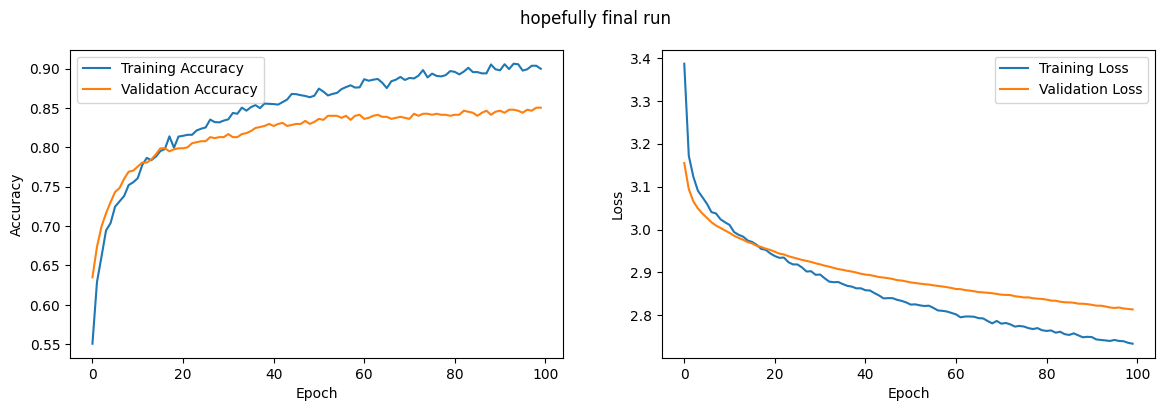

Best train_accuracy: 0.9062
Best train_loss: 2.7338
Best val_accuracy: 0.8503
Best val_loss: 2.8136
Last improvement at epoch: 99


In [16]:
plot_history(comment, history)

2024-07-17 10:03:02.951729: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Test accuracy: 0.8969
Test precision: 0.8938
Test recall: 0.9047
Test F1 score: 0.8992
Prediction time: 5.51 seconds


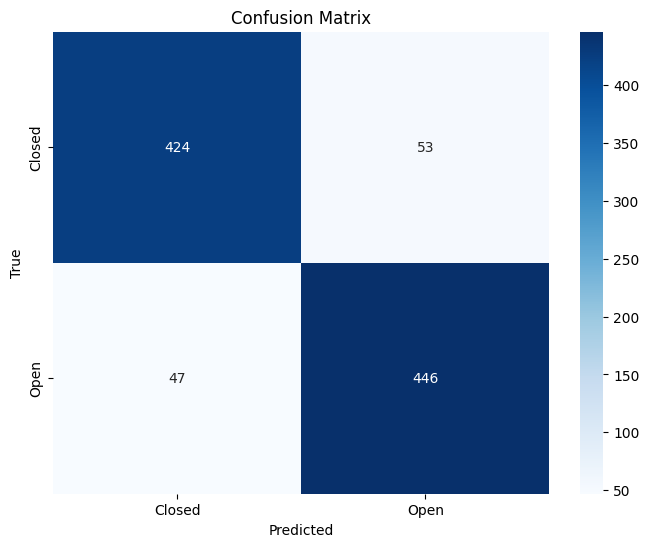

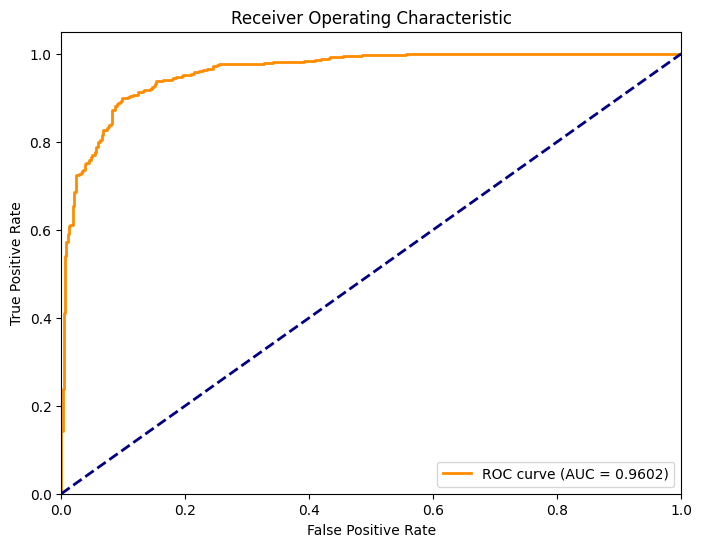

In [17]:
evaluate_model(model, real_test_data)

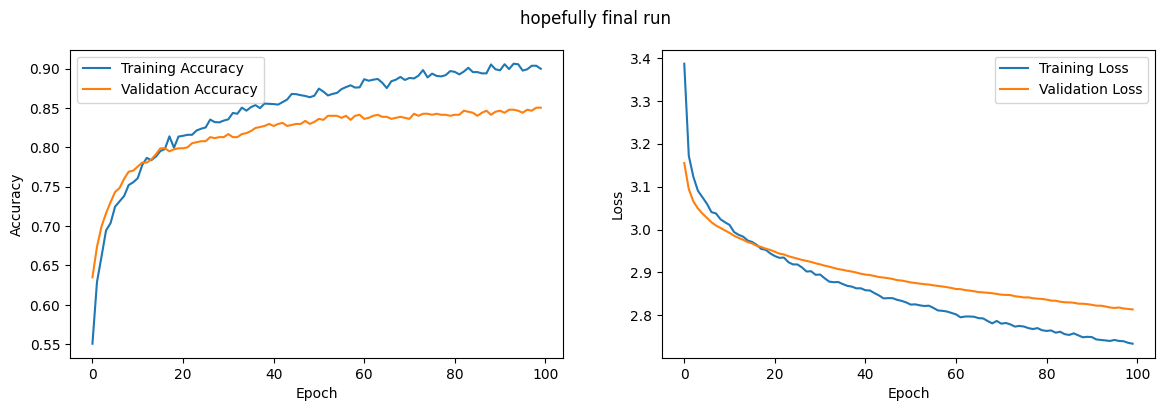

Best train_accuracy: 0.9062
Best train_loss: 2.7338
Best val_accuracy: 0.8503
Best val_loss: 2.8136
Last improvement at epoch: 99


In [18]:
plot_history(comment, history)

Test accuracy: 0.8969
Test precision: 0.8938
Test recall: 0.9047
Test F1 score: 0.8992
Prediction time: 3.02 seconds


2024-07-17 10:03:07.455231: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


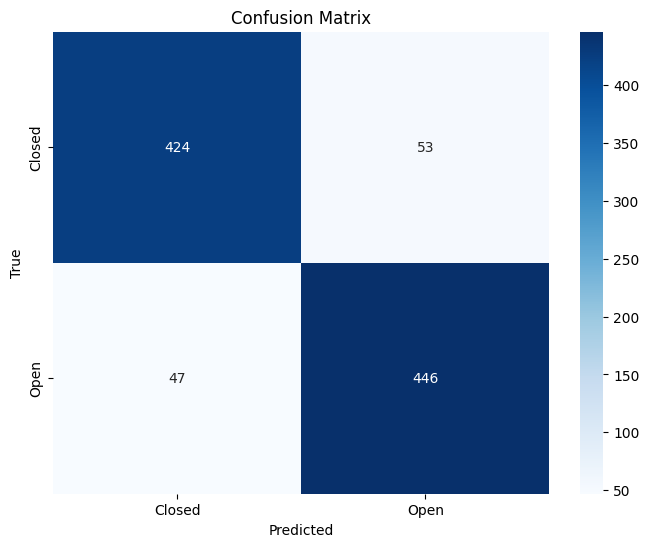

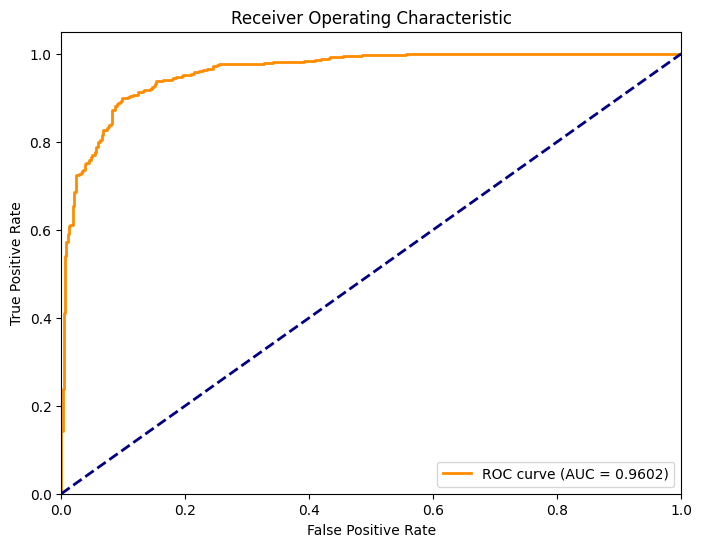

In [19]:
evaluate_model(model, real_test_data)